<a href="https://colab.research.google.com/github/Kittichot2003/GEE_LAB3/blob/main/GE338_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Machine Learning สำหรับการจำแนกการใช้ที่ดิน
## พื้นที่ศึกษา: จังหวัดเพชรบุรี ด้วย Landsat 8
**ภม.338 Geographic Data Science**

### ติดตั้งและนำเข้า Library

In [66]:
!pip install earthengine-api geemap matplotlib seaborn pandas numpy -q

In [67]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ee.Authenticate()
ee.Initialize(project='ee-kittichot6692')

from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Earth Engine initialized')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Earth Engine initialized


---
## ภารกิจที่ 1: Training Strategy

### Training Data จาก GEE Asset

In [68]:
# ============================================================
# โหลด Training Samples ที่สร้างไว้ใน GEE Asset
# ============================================================
all_samples = ee.FeatureCollection(
    'projects/ee-kittichot6692/assets/LAB3_point_byGF'
)

# ตรวจสอบโครงสร้าง
sample_info  = all_samples.first().getInfo()
total_count  = all_samples.size().getInfo()
props        = list(sample_info['properties'].keys())

print(f'✅ Training samples loaded: {total_count} features')
print(f'Properties: {props}')
print('\nตัวอย่าง Feature แรก:')
for k, v in sample_info['properties'].items():
    print(f'  {k}: {v}')

✅ Training samples loaded: 250 features
Properties: ['Class', 'landcover']

ตัวอย่าง Feature แรก:
  Class: 1
  landcover: 1


In [69]:
# ============================================================
#  ปรับ LABEL_COLUMN ให้ตรงกับชื่อ Property จริงในข้อมูล
#    ดูจาก output ของ cell บน เช่น 'landcover', 'class', 'lc'
# ============================================================
LABEL_COLUMN = 'landcover'

class_counts = all_samples.aggregate_histogram(LABEL_COLUMN).getInfo()
print(f'จำนวนตัวอย่างต่อ Class (column: "{LABEL_COLUMN}"):')
for cls, cnt in sorted(class_counts.items()):
    print(f'  Class {cls}: {cnt} samples')

จำนวนตัวอย่างต่อ Class (column: "landcover"):
  Class 1: 50 samples
  Class 2: 50 samples
  Class 3: 50 samples
  Class 4: 50 samples
  Class 5: 50 samples


In [70]:
# ============================================================
# กำหนด Class Names — ปรับให้ตรงกับ Class ในข้อมูลของคุณ
# ============================================================
CLASS_NAMES = {
    1: 'Urban',
    2: 'Forest',
    4: 'Water',
    3: 'Agriculture',
    5: 'Miscellaneous',

}
print('Class mapping:', CLASS_NAMES)

Class mapping: {1: 'Urban', 2: 'Forest', 4: 'Water', 3: 'Agriculture', 5: 'Miscellaneous'}


### 1.2 กำหนดพื้นที่ศึกษา


In [71]:
thailand = ee.FeatureCollection('FAO/GAUL/2015/level1') \
    .filter(ee.Filter.eq('ADM0_NAME', 'Thailand'))
phetchaburi   = thailand.filter(ee.Filter.eq('ADM1_NAME', 'Phetchaburi'))
aoi      = phetchaburi.geometry()
print('✅ AOI: จังหวัดเพชรบุรี')

✅ AOI: จังหวัดเพชรบุรี


In [72]:
Map = geemap.Map(center=[12.68, 101.28], zoom=9)

Map.addLayer(phetchaburi, {'color': '000000'}, 'Phetchaburi boundary')

# Filter แต่ละ class
water = all_samples.filter(ee.Filter.eq('landcover', 1))
agri  = all_samples.filter(ee.Filter.eq('landcover', 2))
urban = all_samples.filter(ee.Filter.eq('landcover', 3))
forest= all_samples.filter(ee.Filter.eq('landcover', 4))
misc  = all_samples.filter(ee.Filter.eq('landcover', 5))

# ใส่สี
Map.addLayer(water,  {'color': '0000FF'}, 'Water')
Map.addLayer(agri,   {'color': 'FFFF00'}, 'Agriculture')
Map.addLayer(urban,  {'color': 'FF0000'}, 'Urban')
Map.addLayer(forest, {'color': '008000'}, 'Forest')
Map.addLayer(misc,   {'color': 'FFA500'}, 'Misc')

Map

Map(center=[12.68, 101.28], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

### 1.3 โหลดและประมวลผล Landsat 8 Imagery

In [73]:
def maskL8sr(image):
    """Cloud mask + scale Landsat 8 SR Collection 2"""
    qa_mask  = image.select('QA_PIXEL').bitwiseAnd(int('11111', 2)).eq(0)
    sat_mask = image.select('QA_RADSAT').eq(0)
    optical  = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    return image.addBands(optical, None, True) \
                .updateMask(qa_mask).updateMask(sat_mask)

l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(aoi) \
    .filterDate('2020-01-01', '2023-12-31') \
    .filter(ee.Filter.calendarRange(11, 3, 'month')) \
    .map(maskL8sr) \
    .median() \
    .clip(aoi)

print('✅ Landsat 8 SR — dry season median composite 2020–2023')
print('Bands:', l8.bandNames().getInfo())

✅ Landsat 8 SR — dry season median composite 2020–2023
Bands: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT']


### 1.4 คำนวณ Spectral Indices

In [74]:
def add_indices(img):
    b, g, r     = img.select('SR_B2'), img.select('SR_B3'), img.select('SR_B4')
    nir, s1, s2 = img.select('SR_B5'), img.select('SR_B6'), img.select('SR_B7')

    return img.addBands([
        nir.subtract(r).divide(nir.add(r)).rename('NDVI'),
        nir.subtract(s1).divide(nir.add(s1)).rename('NDWI'),
        g.subtract(s1).divide(g.add(s1)).rename('MNDWI'),
        s1.subtract(nir).divide(s1.add(nir)).rename('NDBI'),
        nir.subtract(r).multiply(1.5).divide(nir.add(r).add(0.5)).rename('SAVI'),
        nir.subtract(r).multiply(2.5).divide(
            nir.add(r.multiply(6)).subtract(b.multiply(7.5)).add(1)).rename('EVI'),
        s1.add(r).subtract(nir.add(b)).divide(
            s1.add(r).add(nir).add(b)).rename('BSI'),
        g.multiply(4).subtract(s1.multiply(0.25).add(nir.multiply(2.75))).rename('AWEInsh'),
    ])

l8_feat = add_indices(l8)

FEATURES = ['NDVI', 'NDWI', 'MNDWI', 'NDBI', 'SAVI', 'EVI', 'BSI', 'AWEInsh']

print(f'✅ Features ({len(FEATURES)}): {FEATURES}')

✅ Features (8): ['NDVI', 'NDWI', 'MNDWI', 'NDBI', 'SAVI', 'EVI', 'BSI', 'AWEInsh']


### 1.5 Extract  Values ให้ Training Points


In [75]:
has_indices = any(f in props for f in FEATURES)
print(f'Asset has index values already: {has_indices}')

if not has_indices:
    print('Extracting index values from Landsat 8...')
    all_samples = l8_feat.select(FEATURES).sampleRegions(
        collection=all_samples,
        properties=[LABEL_COLUMN],
        scale=30,
        tileScale=8
    )
    print('✅ Extraction done')
else:
    print('✅ Using index values already in asset')

print('Properties:', all_samples.first().propertyNames().getInfo())

Asset has index values already: False
Extracting index values from Landsat 8...
✅ Extraction done
Properties: ['system:index', 'landcover', 'AWEInsh', 'MNDWI', 'SAVI', 'NDBI', 'EVI', 'BSI', 'NDWI', 'NDVI']


### 1.6 แบ่ง Train / Test Split (80/20 Stratified Random)

In [76]:
all_samples = all_samples.randomColumn('random', seed=42)
train_data  = all_samples.filter(ee.Filter.lt('random',  0.8))
test_data   = all_samples.filter(ee.Filter.gte('random', 0.8))

n_train = train_data.size().getInfo()
n_test  = test_data.size().getInfo()
print(f'Train: {n_train}  |  Test: {n_test}')

print('\nTrain samples per class:')
for cls, cnt in sorted(train_data.aggregate_histogram(LABEL_COLUMN).getInfo().items()):
    print(f'  Class {cls} ({CLASS_NAMES.get(int(cls), cls)}): {cnt}')

Train: 209  |  Test: 41

Train samples per class:
  Class 1 (Urban): 45
  Class 2 (Forest): 39
  Class 3 (Agriculture): 42
  Class 4 (Water): 39
  Class 5 (Miscellaneous): 44


---
## ภารกิจที่ 2: compear Agorlithm

### 2.1 Helper Functions

In [77]:
def train_rf(n_trees):
    return ee.Classifier.smileRandomForest(
        numberOfTrees=n_trees, seed=42
    ).train(features=train_data, classProperty=LABEL_COLUMN, inputProperties=FEATURES)


def evaluate(clf):
    cm = test_data.classify(clf).errorMatrix(LABEL_COLUMN, 'classification')
    return {
        'overall_accuracy': cm.accuracy().getInfo(),
        'kappa':            cm.kappa().getInfo(),
        'confusion_matrix': cm.getInfo(),
        'producers_acc':    cm.producersAccuracy().getInfo(),
        'consumers_acc':    cm.consumersAccuracy().getInfo(),
    }

### 2.2 Random Forest

In [ ]:
rf_results = {}

for n in [50, 100, 200]:
    print(f'Training RF {n} trees...', end=' ')
    clf = train_rf(n)
    rf_results[n] = evaluate(clf)
    rf_results[n]['classifier'] = clf
    print(f'OA={rf_results[n]["overall_accuracy"]:.4f}  Kappa={rf_results[n]["kappa"]:.4f}')

best_rf = rf_results[100]['classifier']
print('\n Best RF: 100 trees')

Training RF 50 trees... OA=0.7317  Kappa=0.6622
Training RF 100 trees... OA=0.7317  Kappa=0.6622
Training RF 200 trees... 

### 2.3 Gradient Tree Boost

In [79]:
print('Training Gradient Tree Boost...', end=' ')
gtb_clf = ee.Classifier.smileGradientTreeBoost(
    numberOfTrees=100, shrinkage=0.05, samplingRate=0.7, seed=42
).train(features=train_data, classProperty=LABEL_COLUMN, inputProperties=FEATURES)

gtb_result = evaluate(gtb_clf)
print(f'OA={gtb_result["overall_accuracy"]:.4f}  Kappa={gtb_result["kappa"]:.4f}')

Training Gradient Tree Boost... OA=0.7561  Kappa=0.6906


### 2.5 Confusion Matrix (RF + GTB)

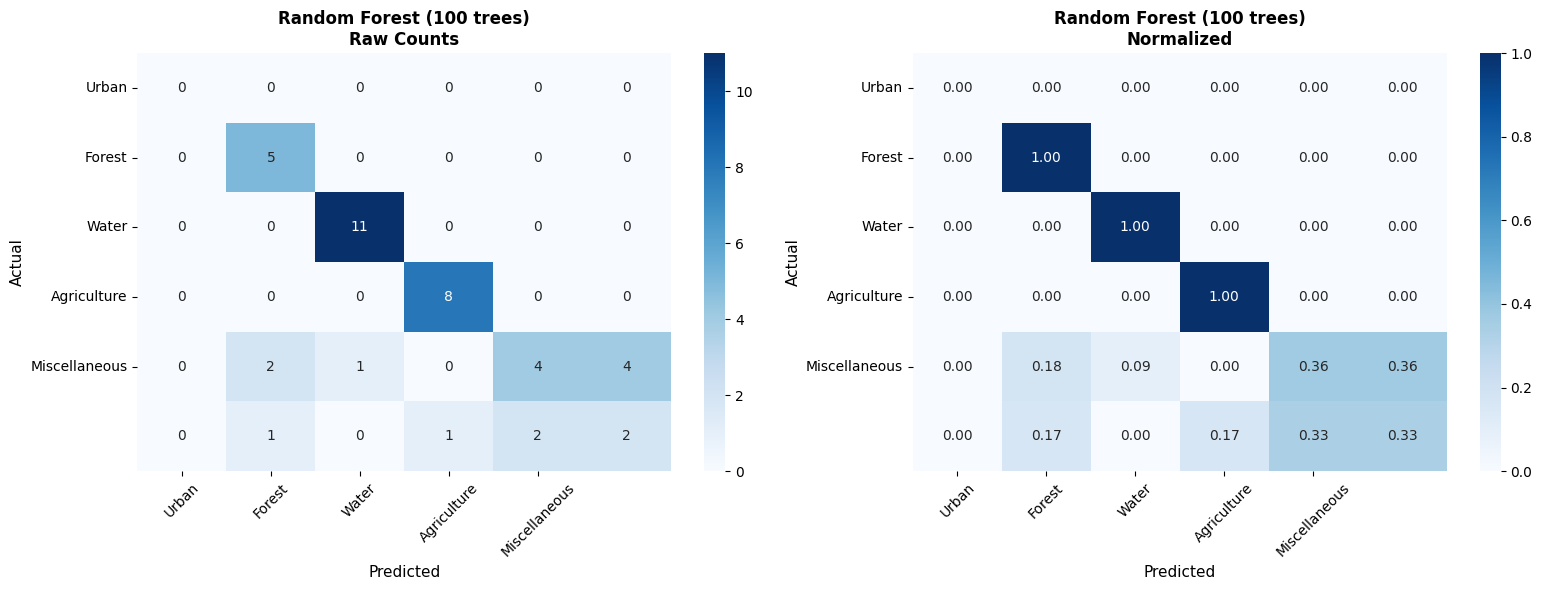

✅ Saved: figures/confusion_matrix_RF.png


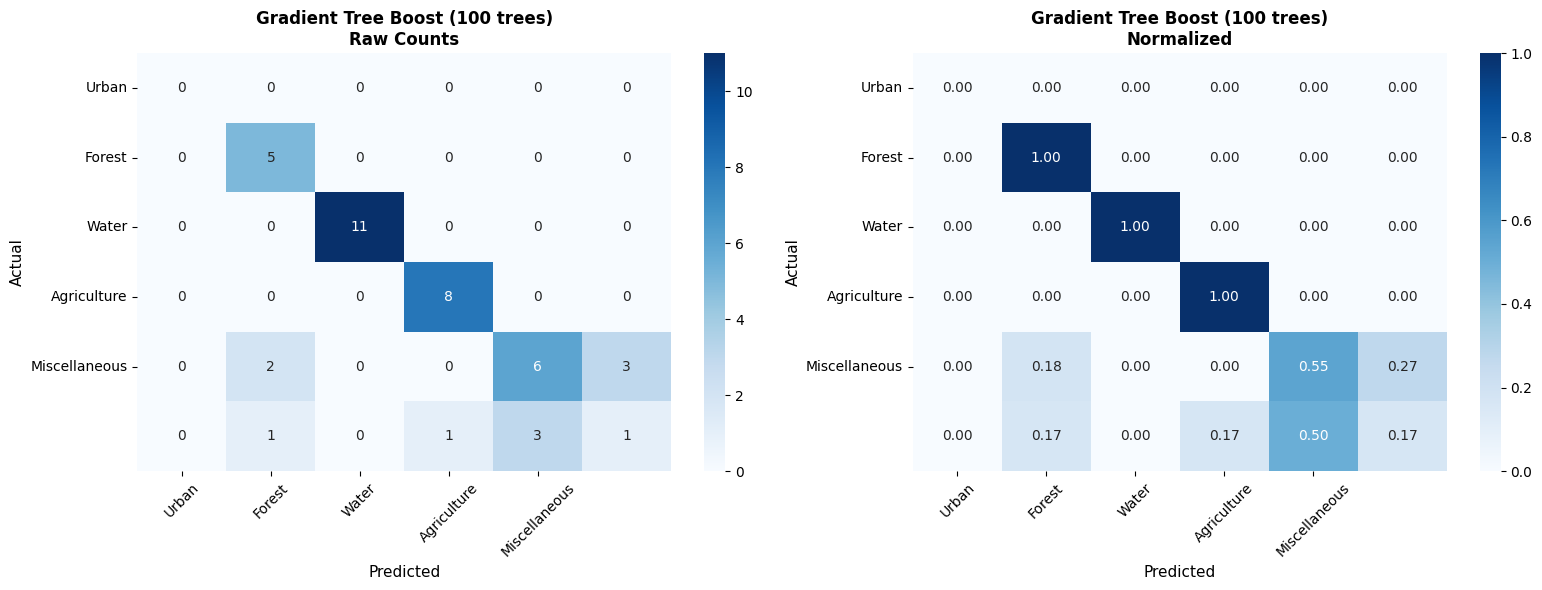

✅ Saved: figures/confusion_matrix_GTB.png


In [80]:
import os
os.makedirs('/content/drive/MyDrive/figures', exist_ok=True)

def plot_cm(cm_data, class_names, title, filename):
    cm     = np.array(cm_data)
    labels = list(class_names.values())
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[0])
    axes[0].set_title(f'{title}\nRaw Counts', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Actual', fontsize=11)
    axes[0].set_xlabel('Predicted', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)

    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sum,
                        out=np.zeros_like(cm, dtype=float), where=row_sum != 0)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title(f'{title}\nNormalized', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Actual', fontsize=11)
    axes[1].set_xlabel('Predicted', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/figures/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: figures/{filename}')


plot_cm(rf_results[100]['confusion_matrix'], CLASS_NAMES,
        'Random Forest (100 trees)', 'confusion_matrix_RF.png')

plot_cm(gtb_result['confusion_matrix'], CLASS_NAMES,
        'Gradient Tree Boost (100 trees)', 'confusion_matrix_GTB.png')

### 2.6 Per-Class Metrics

In [81]:
def per_class_metrics(cm_data, class_names):
    cm, rows = np.array(cm_data), []
    for i, (cid, cname) in enumerate(class_names.items()):
        if i >= len(cm): continue
        tp   = cm[i, i]
        prod = tp / cm[i, :].sum()  if cm[i, :].sum()  > 0 else 0
        user = tp / cm[:, i].sum()  if cm[:, i].sum()  > 0 else 0
        f1   = 2*prod*user/(prod+user) if (prod+user) > 0 else 0
        rows.append({'Class': cname,
                     "Producer's (Recall)": f'{prod:.3f}',
                     "User's (Precision)": f'{user:.3f}',
                     'F1': f'{f1:.3f}'})
    return pd.DataFrame(rows)


print('══ Random Forest ══')
print(per_class_metrics(rf_results[100]['confusion_matrix'], CLASS_NAMES).to_string(index=False))
print(f'OA={rf_results[100]["overall_accuracy"]:.4f}  Kappa={rf_results[100]["kappa"]:.4f}')

print('\n══ Gradient Tree Boost ══')
print(per_class_metrics(gtb_result['confusion_matrix'], CLASS_NAMES).to_string(index=False))
print(f'OA={gtb_result["overall_accuracy"]:.4f}  Kappa={gtb_result["kappa"]:.4f}')

══ Random Forest ══
        Class Producer's (Recall) User's (Precision)    F1
        Urban               0.000              0.000 0.000
       Forest               1.000              0.625 0.769
        Water               1.000              0.917 0.957
  Agriculture               1.000              0.889 0.941
Miscellaneous               0.364              0.667 0.471
OA=0.7317  Kappa=0.6622

══ Gradient Tree Boost ══
        Class Producer's (Recall) User's (Precision)    F1
        Urban               0.000              0.000 0.000
       Forest               1.000              0.625 0.769
        Water               1.000              1.000 1.000
  Agriculture               1.000              0.889 0.941
Miscellaneous               0.545              0.667 0.600
OA=0.7561  Kappa=0.6906


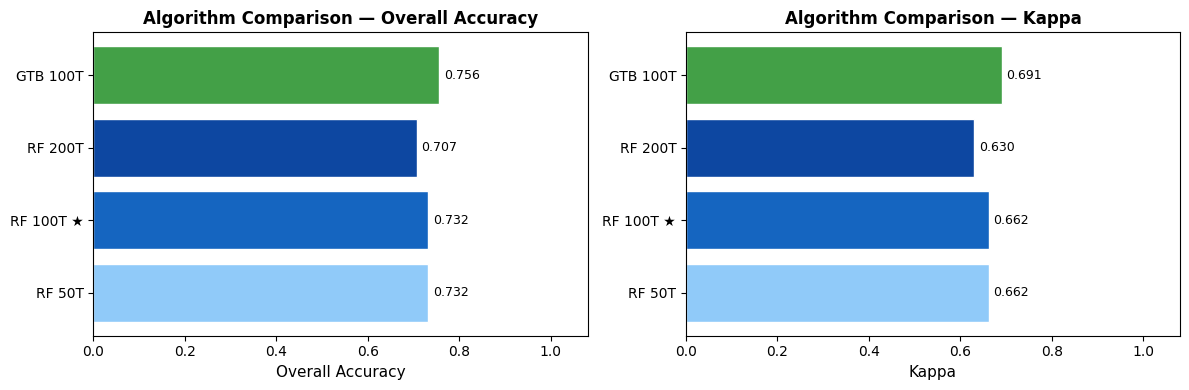

✅ Saved: figures/algorithm_comparison.png


In [82]:
# Bar chart Algorithm Comparison
cmp_labels = ['RF 50T', 'RF 100T ★', 'RF 200T', 'GTB 100T']
oa_vals    = [rf_results[50]['overall_accuracy'], rf_results[100]['overall_accuracy'],
              rf_results[200]['overall_accuracy'], gtb_result['overall_accuracy']]
kappa_vals = [rf_results[50]['kappa'], rf_results[100]['kappa'],
              rf_results[200]['kappa'], gtb_result['kappa']]
colors     = ['#90CAF9', '#1565C0', '#0D47A1', '#43A047']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, title in [(ax1, oa_vals, 'Overall Accuracy'), (ax2, kappa_vals, 'Kappa')]:
    bars = ax.barh(cmp_labels, vals, color=colors, edgecolor='white')
    ax.set_xlabel(title, fontsize=11)
    ax.set_title(f'Algorithm Comparison — {title}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.08)
    for b, v in zip(bars, vals):
        ax.text(v+0.01, b.get_y()+b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/algorithm_comparison.png')

---
## ภารกิจที่ 3: Feature Importance Analysis

In [83]:
importance_raw = best_rf.explain().getInfo()['importance']
df_imp = pd.DataFrame({
    'Feature':    list(importance_raw.keys()),
    'Importance': list(importance_raw.values())
}).sort_values('Importance', ascending=False).reset_index(drop=True)
df_imp['Pct'] = df_imp['Importance'] / df_imp['Importance'].sum() * 100

print('=== Feature Importance (Spectral Indices) ===')
print(df_imp.to_string(index=False))

=== Feature Importance (Spectral Indices) ===
Feature  Importance       Pct
AWEInsh   96.765011 13.873920
    EVI   93.095403 13.347781
  MNDWI   92.103932 13.205626
   NDVI   86.497267 12.401757
   NDWI   84.497938 12.115098
    BSI   83.475612 11.968520
   SAVI   80.630756 11.560632
   NDBI   80.393856 11.526666


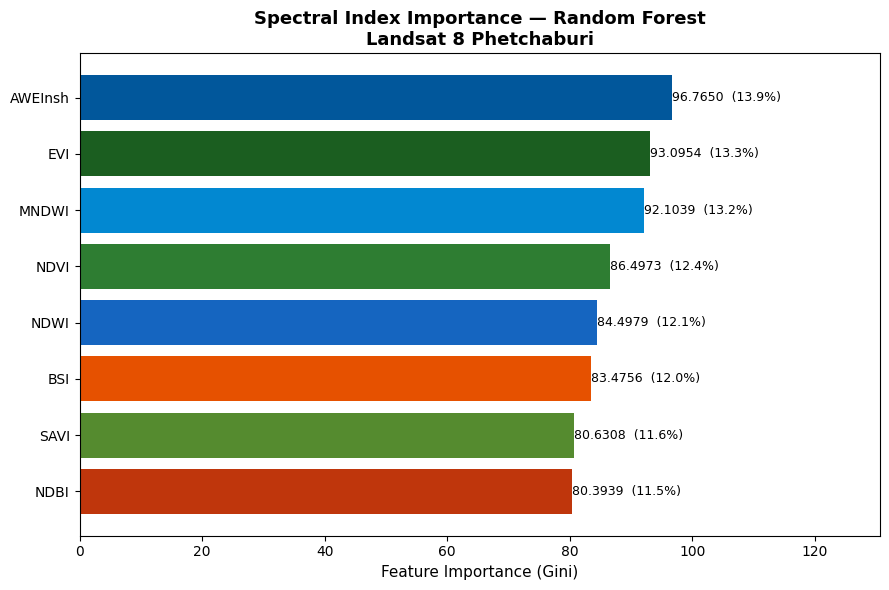

✅ Saved: figures/feature_importance.png


In [84]:
# Color palette สำหรับแต่ละ Index
INDEX_COLORS = {
    'NDVI':    '#2E7D32',
    'NDWI':    '#1565C0',
    'MNDWI':   '#0288D1',
    'NDBI':    '#BF360C',
    'SAVI':    '#558B2F',
    'EVI':     '#1B5E20',
    'BSI':     '#E65100',
    'AWEInsh': '#01579B',
}
bar_colors = [INDEX_COLORS.get(f, '#607D8B') for f in df_imp['Feature'][::-1]]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(df_imp['Feature'][::-1], df_imp['Importance'][::-1], color=bar_colors)
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Spectral Index Importance — Random Forest\nLandsat 8 Phetchaburi',
             fontsize=13, fontweight='bold')
for b, v, pct in zip(bars, df_imp['Importance'][::-1], df_imp['Pct'][::-1]):
    ax.text(v+0.001, b.get_y()+b.get_height()/2,
            f'{v:.4f}  ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlim(0, df_imp['Importance'].max() * 1.35)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/feature_importance.png')

In [85]:
# ทดสอบตัด Index ที่ Importance < 5%
top_feats = df_imp[df_imp['Pct'] >= 5.0]['Feature'].tolist()
low_feats = df_imp[df_imp['Pct'] <  5.0]['Feature'].tolist()

print(f'Top indices (≥5%): {top_feats}')
print(f'Low indices (<5%): {low_feats}')

rf_top    = ee.Classifier.smileRandomForest(numberOfTrees=100, seed=42).train(
    features=train_data, classProperty=LABEL_COLUMN, inputProperties=top_feats
)
res_top   = evaluate(rf_top)
delta     = res_top['overall_accuracy'] - rf_results[100]['overall_accuracy']

print(f'\nAll indices ({len(FEATURES)})  OA={rf_results[100]["overall_accuracy"]:.4f}')
print(f'Top indices ({len(top_feats)})  OA={res_top["overall_accuracy"]:.4f}')
print(f'Δ               {delta:+.4f}')

Top indices (≥5%): ['AWEInsh', 'EVI', 'MNDWI', 'NDVI', 'NDWI', 'BSI', 'SAVI', 'NDBI']
Low indices (<5%): []

All indices (8)  OA=0.7317
Top indices (8)  OA=0.7073
Δ               -0.0244


---
## ภารกิจที่ 4: Uncertainty Assessment

In [86]:
# Classification Map
classified_map = l8_feat.select(FEATURES).classify(best_rf)

# Uncertainty = 1 − max class probability
rf_multiprob = ee.Classifier.smileRandomForest(
    numberOfTrees=100, seed=42
).setOutputMode('MULTIPROBABILITY').train(
    features=train_data, classProperty=LABEL_COLUMN, inputProperties=FEATURES
)
prob_array  = l8_feat.select(FEATURES).classify(rf_multiprob)
max_prob    = prob_array.arrayReduce(ee.Reducer.max(), [0]).arrayGet([0])
uncertainty = ee.Image(1).subtract(max_prob).rename('uncertainty')

print('✅ Classification and uncertainty maps ready')

✅ Classification and uncertainty maps ready


In [87]:
# แสดงแผนที่
Map2 = geemap.Map(center=[12.68, 101.28], zoom=9)
Map2.addLayer(l8, {'bands':['SR_B4','SR_B3','SR_B2'],'min':0,'max':0.3},
              'Landsat 8 True Color')

palette = ['#0034FF','#00BFFF','#FFFF00','#006400','#FF2200','#D2B48C']
Map2.addLayer(classified_map, {'min':1,'max':6,'palette':palette}, 'Land Cover (RF)')
#Map2.addLayer(uncertainty, {'min':0,'max':0.5,'palette':['white','orange','red']},
#              'Uncertainty')
#Map2.addLayer(Phetchaburi, {'color':'000000'}, 'ขอบเขต')

Map2.add_legend(title='Land Cover',
                legend_dict={name: col for name, col in
                             zip(CLASS_NAMES.values(), palette)})
Map2

Map(center=[12.68, 101.28], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

In [88]:
# สถิติ
def area_km2(mask):
    return ee.Image.pixelArea().updateMask(mask) \
        .reduceRegion(ee.Reducer.sum(), aoi, 30, maxPixels=1e10) \
        .get('area').getInfo() / 1e6

a_low  = area_km2(uncertainty.lte(0.15))
a_med  = area_km2(uncertainty.gt(0.15).And(uncertainty.lte(0.30)))
a_high = area_km2(uncertainty.gt(0.30))
a_tot  = a_low + a_med + a_high

print('=== Uncertainty Zones ===')
print(f'Low   (≤15%)  : {a_low:8.1f} km²  ({a_low/a_tot*100:.1f}%)')
print(f'Medium(15-30%): {a_med:8.1f} km²  ({a_med/a_tot*100:.1f}%)')
print(f'High  (>30%)  : {a_high:8.1f} km²  ({a_high/a_tot*100:.1f}%)')

=== Uncertainty Zones ===
Low   (≤15%)  :      0.0 km²  (0.0%)
Medium(15-30%):   2394.2 km²  (38.3%)
High  (>30%)  :   3864.6 km²  (61.7%)


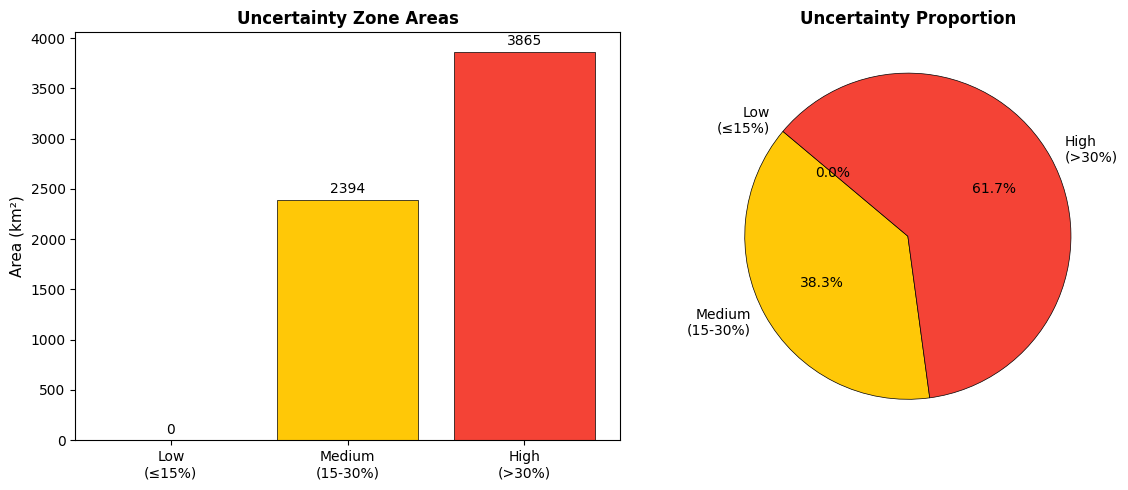

✅ Saved: figures/uncertainty.png


In [89]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
unc_labels = ['Low\n(≤15%)', 'Medium\n(15-30%)', 'High\n(>30%)']
unc_areas  = [a_low, a_med, a_high]
unc_colors = ['#4CAF00', '#FFC807', '#F44336']

ax1.bar(unc_labels, unc_areas, color=unc_colors, edgecolor='black', lw=0.5)
ax1.set_ylabel('Area (km²)', fontsize=11)
ax1.set_title('Uncertainty Zone Areas', fontsize=12, fontweight='bold')
for i, v in enumerate(unc_areas):
    ax1.text(i, v + a_tot*0.01, f'{v:.0f}', ha='center', fontsize=10)

ax2.pie(unc_areas, labels=unc_labels, colors=unc_colors,
        autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor':'black','linewidth':0.5})
ax2.set_title('Uncertainty Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LAB3_pic/uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/uncertainty.png')

In [90]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
lc_oa     = []

for frac in fractions:
    subset = all_samples.filter(ee.Filter.lt('random', frac * 0.8))
    n_sub  = subset.size().getInfo()
    print(f'{frac:.0%} → {n_sub} samples...', end=' ')
    if n_sub < 12:
        print('too few, skip')
        lc_oa.append(None)
        continue
    clf_sub = ee.Classifier.smileRandomForest(numberOfTrees=100, seed=42).train(
        features=subset, classProperty=LABEL_COLUMN, inputProperties=FEATURES
    )
    res = evaluate(clf_sub)
    lc_oa.append(res['overall_accuracy'])
    print(f'OA={res["overall_accuracy"]:.4f}')

20% → 38 samples... OA=0.7317
40% → 84 samples... OA=0.7317
60% → 129 samples... OA=0.7073
80% → 170 samples... OA=0.7317
100% → 209 samples... OA=0.7317


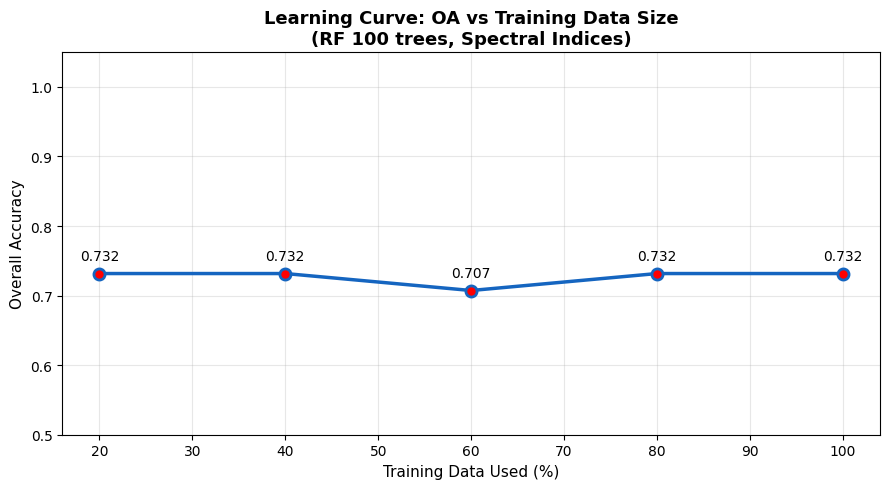

✅ Saved: figures/learning_curve.png


In [94]:
valid = [(f*100, oa) for f, oa in zip(fractions, lc_oa) if oa is not None]
xs, ys = zip(*valid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, ys, 'o-', color='#1565C0', lw=2.5, ms=8,
        markerfacecolor='Red', markeredgewidth=2)
for x, y in zip(xs, ys):
    ax.annotate(f'{y:.3f}', (x, y), xytext=(0,10),
                textcoords='offset points', ha='center', fontsize=10)
ax.set_xlabel('Training Data Used (%)', fontsize=11)
ax.set_ylabel('Overall Accuracy', fontsize=11)
ax.set_title('Learning Curve: OA vs Training Data Size\n(RF 100 trees, Spectral Indices)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LAB3_pic/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/learning_curve.png')

---
## Export แผนที่

In [95]:
for img, desc, prefix in [
    (classified_map, 'Phetchaburi_LandCover_RF',  'phetchaburi_landcover_rf'),
    (uncertainty,    'Phetchaburi_Uncertainty_RF', 'phetchaburi_uncertainty_rf'),
]:
    task = ee.batch.Export.image.toDrive(
        image=img, description=desc, folder='LAB3_pic',
        fileNamePrefix=prefix, scale=30, region=aoi,
        crs='EPSG:32648', maxPixels=1e13
    )
    task.start()
    print(f'✅ {desc}: {task.status()["state"]}')


✅ Phetchaburi_LandCover_RF: READY
✅ Phetchaburi_Uncertainty_RF: READY


In [93]:
summary = pd.DataFrame([
    {'Algorithm': 'RF  50 trees',   'OA': f"{rf_results[50]['overall_accuracy']:.4f}",  'Kappa': f"{rf_results[50]['kappa']:.4f}"},
    {'Algorithm': 'RF 100 trees ★', 'OA': f"{rf_results[100]['overall_accuracy']:.4f}", 'Kappa': f"{rf_results[100]['kappa']:.4f}"},
    {'Algorithm': 'RF 200 trees',   'OA': f"{rf_results[200]['overall_accuracy']:.4f}", 'Kappa': f"{rf_results[200]['kappa']:.4f}"},
    {'Algorithm': 'GTB 100 trees',  'OA': f"{gtb_result['overall_accuracy']:.4f}",      'Kappa': f"{gtb_result['kappa']:.4f}"},
])

print('════════════════════════════════')
print('         FINAL RESULTS')
print('    Features: Spectral Indices')
print('════════════════════════════════')
print(summary.to_string(index=False))
print('\n★ = Selected model for final map')

════════════════════════════════
         FINAL RESULTS
    Features: Spectral Indices
════════════════════════════════
     Algorithm     OA  Kappa
  RF  50 trees 0.7317 0.6622
RF 100 trees ★ 0.7317 0.6622
  RF 200 trees 0.7073 0.6304
 GTB 100 trees 0.7561 0.6906

★ = Selected model for final map
